In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from vae import VariationalAutoEncoder, kl_loss_function, mse_loss_function, sample

In [69]:
device = torch.device('mps')
batch_size = 120
epochs = 30

In [70]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((32, 32)) 
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

In [4]:
def VAE_train(model, dataloader, optimizer, epochs):
    for epoch in range(epochs):
        mse_loss_sum = 0
        kl_loss_sum = 0
        loss_sum = 0
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        pbar.set_description(f"Epoch {epoch} - Training")
        for i, batch in pbar:
            x, _ = batch
            x = x.to(device)
            mean, log_var = model.encoder(x)
            z_sample = sample(mean, log_var)
            x_bar = model.decoder(z_sample)

            mse_loss = mse_loss_function(x, x_bar)
            kl_loss = kl_loss_function(mean, log_var)
            loss = torch.mean(mse_loss + kl_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_loss_sum += mse_loss.item()
            kl_loss_sum += kl_loss.item()
            loss_sum += loss.item()
            pbar.set_postfix({'mse_loss' : mse_loss_sum / (i+1), 'kl_loss' : kl_loss_sum / (i+1), 'loss' : loss_sum /(i+1)})

    return model

In [5]:
image_shape = [batch_size, 1, 32, 32]
model = VariationalAutoEncoder(latent_dim=10, image_shape=image_shape).to(device)
optimizer = torch.optim.Adam(model.parameters())
model.train()
model = VAE_train(model, dataloader, optimizer, epochs=epochs)

Epoch 29 - Training: 100%|██████████| 500/500 [00:11<00:00, 43.15it/s, mse_loss=1.59e+3, kl_loss=1.49e+3, loss=3.08e+3]


In [92]:
latent_images = []
labels = []

model.eval()
with torch.no_grad():
    for image, label in dataloader:
        image = image.to(device)
        mean, log_var = model.encoder(image)
        z = sample(mean, log_var)
        latent_images.append(z)
        labels.append(label)

In [93]:
# Convertir listas a tensores
latent_images = torch.cat(latent_images)
labels = torch.cat(labels)

In [94]:
latent_images.shape, labels.shape

(torch.Size([60000, 10]), torch.Size([60000]))

In [95]:
from torch.utils.data import Dataset

class LatentDataset(Dataset):
    def __init__(self, latents, labels):
        self.latents = latents
        self.labels = labels

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.labels[idx]

# Crear el dataset con las codificaciones latentes
latent_mnist_dataset = LatentDataset(latent_images, labels)

In [96]:
from torch.utils.data import DataLoader, Subset

# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_1 = [i for i, (img, label) in enumerate(latent_mnist_dataset) if label == 1]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_1 = Subset(latent_mnist_dataset, indices_clase_1)

latent_dataloader = DataLoader(latent_dataset_clase_1, batch_size=32, shuffle=True)

Hacemos un modelo de difusión muy sencillo a modo de prueba.

In [97]:
T = 1000  # Número de pasos de difusión
betas = torch.linspace(1e-4, 0.02, T).to(device)  # Coeficiente beta para cada paso de difusión
alphas = 1 - betas
alpha_hat = torch.cumprod(alphas, dim=0)  # Producto acumulado de alphas

In [98]:
def add_noise(x, t):
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None]
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat[t])[:, None]
    epsilon = torch.randn_like(x)
    return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

In [102]:
class DiffusionModel(nn.Module):
    def __init__(self, latent_dim):
        super(DiffusionModel, self).__init__()
        self.fc1 = nn.Linear(latent_dim + 1, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 512)
        self.fc4 = nn.Linear(512, 256)
        self.fc5 = nn.Linear(256, 128)
        self.fc6 = nn.Linear(128, latent_dim)

    def forward(self, x, t):
        """
        x: Latente con ruido en el paso t.
        t: Paso de tiempo (agregado como característica adicional).
        """
        t_embedded = t.unsqueeze(1).float()  # Asegurar que t tiene una dimensión para concatenar
        x = torch.cat([x, t_embedded], dim=1)  # Concatenar x con el tiempo t
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        return self.fc6(x)

In [103]:
import torch.optim as optim

# Definir el modelo de difusión
latent_dim = latent_images.shape[1]  # Dimensión del espacio latente
diffusion_model = DiffusionModel(latent_dim).to(device)
optimizer = optim.Adam(diffusion_model.parameters(), lr=1e-4)

# Bucle de entrenamiento
epochs = 50

for epoch in range(epochs):
    diffusion_model.train()
    running_loss = 0.0

    for latents, _ in latent_dataloader:  # Usamos nuestro DataLoader de codificaciones latentes
        # Selecciona un paso t aleatorio para cada ejemplo en el batch
        t = torch.randint(0, T, (latents.size(0),))
        t = t.to(device)

        latents = latents.to(device)

        # añadimos ruido a las imágenes
        noisy_latents, noise = add_noise(latents, t)

        # Predecir el ruido usando el modelo de difusión
        noise_pred = diffusion_model(noisy_latents, t)

        # Calcular la pérdida como la MSE entre el ruido real y el ruido predicho
        loss = F.mse_loss(noise_pred, noise)

        # Optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(latent_dataloader)}')

Epoch [1/50], Loss: 1.039048703643383
Epoch [2/50], Loss: 1.0113559221204422
Epoch [3/50], Loss: 0.9941692970940287
Epoch [4/50], Loss: 1.001248836517334
Epoch [5/50], Loss: 0.9839232580921661
Epoch [6/50], Loss: 0.9384101903269076
Epoch [7/50], Loss: 0.8711976660371392
Epoch [8/50], Loss: 0.7747590239579079
Epoch [9/50], Loss: 0.6813835676812448
Epoch [10/50], Loss: 0.6075879788794224
Epoch [11/50], Loss: 0.5205032096654882
Epoch [12/50], Loss: 0.4525134165140125
Epoch [13/50], Loss: 0.38561843681674435
Epoch [14/50], Loss: 0.34894726330070136
Epoch [15/50], Loss: 0.30380663395775437
Epoch [16/50], Loss: 0.28760006261097876
Epoch [17/50], Loss: 0.2839066141165828
Epoch [18/50], Loss: 0.26390170810911895
Epoch [19/50], Loss: 0.26632956175301314
Epoch [20/50], Loss: 0.26677657953370804
Epoch [21/50], Loss: 0.2749407728913271
Epoch [22/50], Loss: 0.26126051683561496
Epoch [23/50], Loss: 0.2684158739673583
Epoch [24/50], Loss: 0.26990714061881693
Epoch [25/50], Loss: 0.2754781337287189
Ep

In [108]:
def sample_latent(diffusion_model, latent_dim, T):
    """
    Genera una muestra a partir de ruido puro.
    """
    with torch.no_grad():
        # Comenzar desde ruido puro
        z = torch.randn(1, latent_dim).to(device)

        # Revertir el proceso de difusión paso a paso
        for t in reversed(range(T)):
            t_tensor = torch.full((1,), t, dtype=torch.long).to(device)
            noise_pred = diffusion_model(z, t_tensor)
            z = (z - torch.sqrt(betas[t]) * noise_pred) / torch.sqrt(1 - betas[t])

    return z

In [109]:
z = sample_latent(diffusion_model, latent_dim, T)

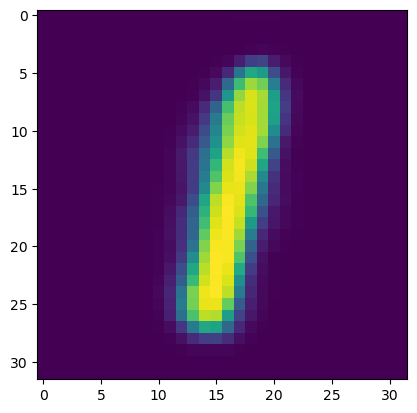

In [110]:
import matplotlib.pyplot as plt

model.eval()

x_bar = model.decoder(z)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())